In [1]:
import pandas as pd

data = {
    'policy_id': [1, 2, 3, 4, 5, 6],
    'region': ['US', 'EU', 'APAC', 'US', 'EU', 'APAC'],
    'peril_type': ['Windstorm', 'Flood', 'Earthquake', 'Flood', 'Windstorm', 'Flood'],
    'premium': [2000000, 1000000, 3000000, 1500000, 2500000, 1200000],
    'expected_loss': [1200000, 400000, 2400000, 1000000, 1500000, 800000],
    'capital_required': [800000, 600000, 1100000, 700000, 1300000, 500000]
}

df = pd.DataFrame(data)

In [2]:
df.head()

,policy_id,region,peril_type,premium,expected_loss,capital_required
0,1,US,Windstorm,2000000,1200000,800000
1,2,EU,Flood,1000000,400000,600000
2,3,APAC,Earthquake,3000000,2400000,1100000
3,4,US,Flood,1500000,1000000,700000
4,5,EU,Windstorm,2500000,1500000,1300000


In [19]:
print(df)

   policy_id region  peril_type  premium  expected_loss  capital_required
0          1     US   Windstorm  2000000        1200000            800000
1          2     EU       Flood  1000000         400000            600000
2          3   APAC  Earthquake  3000000        2400000           1100000
3          4     US       Flood  1500000        1000000            700000
4          5     EU   Windstorm  2500000        1500000           1300000
5          6   APAC       Flood  1200000         800000            500000


In [38]:
f = df[(df["region"] == "US") | (df["region"] == "EU")]
print(f)

   policy_id region peril_type  premium  expected_loss  capital_required
0          1     US  Windstorm  2000000        1200000            800000
1          2     EU      Flood  1000000         400000            600000
3          4     US      Flood  1500000        1000000            700000
4          5     EU  Windstorm  2500000        1500000           1300000


In [41]:
filtered_new = f[f["expected_loss"] >= 1000000]
print(filtered_new)

   policy_id region peril_type  premium  expected_loss  capital_required
0          1     US  Windstorm  2000000        1200000            800000
3          4     US      Flood  1500000        1000000            700000
4          5     EU  Windstorm  2500000        1500000           1300000


In [55]:
flooded = df[df["peril_type"] == "Flood"]
flooded = flooded.sort_values(by="expected_loss", ascending = False)
flood2 = flooded.sort_values(by="policy_id")
print(flooded)
print(flood2)


   policy_id region peril_type  premium  expected_loss  capital_required
3          4     US      Flood  1500000        1000000            700000
5          6   APAC      Flood  1200000         800000            500000
1          2     EU      Flood  1000000         400000            600000
   policy_id region peril_type  premium  expected_loss  capital_required
1          2     EU      Flood  1000000         400000            600000
3          4     US      Flood  1500000        1000000            700000
5          6   APAC      Flood  1200000         800000            500000


In [59]:
df["peril_type"] = df["peril_type"].str.upper()
df["region"] = df["region"].str.upper()
print(df)

   policy_id region  peril_type  premium  expected_loss  capital_required
0          1     US   WINDSTORM  2000000        1200000            800000
1          2     EU       FLOOD  1000000         400000            600000
2          3   APAC  EARTHQUAKE  3000000        2400000           1100000
3          4     US       FLOOD  1500000        1000000            700000
4          5     EU   WINDSTORM  2500000        1500000           1300000
5          6   APAC       FLOOD  1200000         800000            500000


In [63]:
df["cl_ratio"] = df["expected_loss"] / df["capital_required"]
dfsorted = df[df["cl_ratio"] > 1.3]
display(dfsorted)

,policy_id,region,peril_type,premium,expected_loss,capital_required,cl_ratio
0,1,US,WINDSTORM,2000000,1200000,800000,1.500000
2,3,APAC,EARTHQUAKE,3000000,2400000,1100000,2.181818
3,4,US,FLOOD,1500000,1000000,700000,1.428571
5,6,APAC,FLOOD,1200000,800000,500000,1.600000


      Portfolio A  Portfolio B
mean     0.050580     0.060625
std      0.029376     0.149618
min     -0.047238    -0.391058
max      0.165582     0.528966


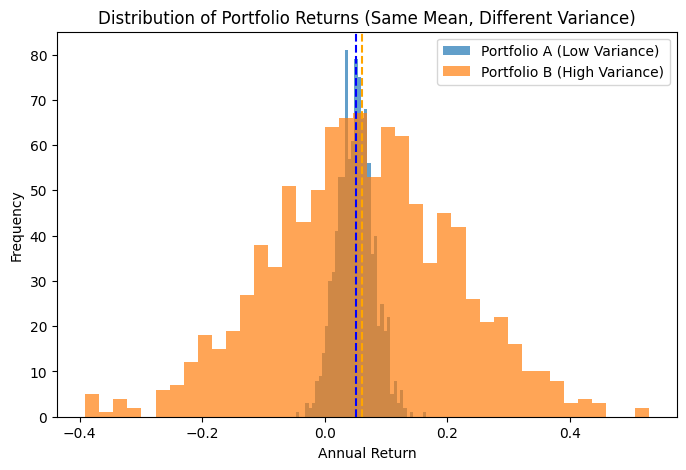

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Simulate 1,000 possible annual returns for each portfolio
np.random.seed(42)

# Portfolio A: mean 5%, low volatility (std dev = 3%)
# Portfolio B: mean 5%, high volatility (std dev = 15%)
returns_A = np.random.normal(0.05, 0.03, 1000)
returns_B = np.random.normal(0.05, 0.15, 1000)

# Create dataframe for easy comparison
df = pd.DataFrame({
    "Portfolio A": returns_A,
    "Portfolio B": returns_B
})

# Calculate summary stats
summary = df.agg(['mean', 'std', 'min', 'max'])
print(summary)

# Plot the distributions
plt.figure(figsize=(8,5))
plt.hist(returns_A, bins=40, alpha=0.7, label='Portfolio A (Low Variance)')
plt.hist(returns_B, bins=40, alpha=0.7, label='Portfolio B (High Variance)')
plt.axvline(df['Portfolio A'].mean(), color='blue', linestyle='--')
plt.axvline(df['Portfolio B'].mean(), color='orange', linestyle='--')
plt.title("Distribution of Portfolio Returns (Same Mean, Different Variance)")
plt.xlabel("Annual Return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [5]:
# Set random seed for reproducibility
np.random.seed(42)

# Create date range (1 year of trading days)
dates = pd.date_range(start="2024-01-01", periods=252, freq="B")

# Simulate daily returns
mean_return = 0.0005  # ~0.05% per day
low_vol = 0.01        # 1% daily standard deviation
high_vol = 0.03       # 3% daily standard deviation

# Generate random returns
returns_low_vol = np.random.normal(mean_return, low_vol, len(dates))
returns_high_vol = np.random.normal(mean_return, high_vol, len(dates))

In [6]:
df = pd.DataFrame({
    "Low Volatility Asset": returns_low_vol,
    "High Volatility Asset": returns_high_vol
}, index=dates)

# Convert to cumulative returns
cumulative_returns = (1 + df).cumprod() - 1

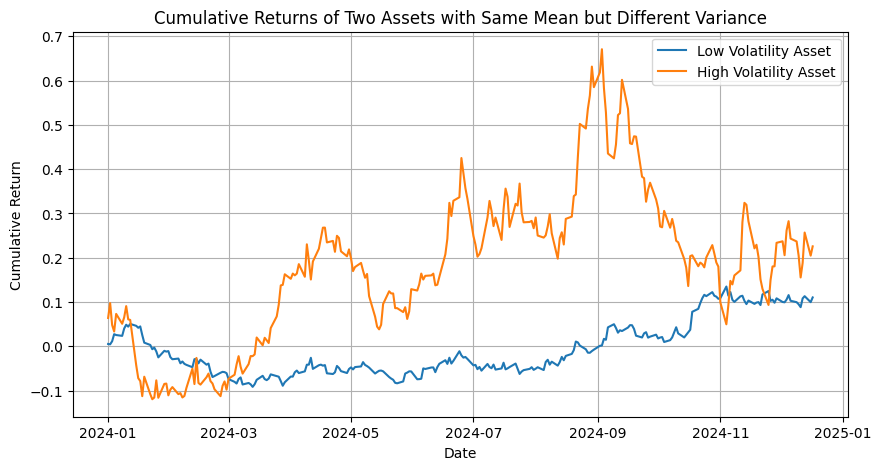

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(cumulative_returns, label=cumulative_returns.columns)
plt.title("Cumulative Returns of Two Assets with Same Mean but Different Variance")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
import plotly.express as px

# Sample portfolio data
portfolio = pd.DataFrame({
    'Peril': ['Hurricane', 'Flood', 'Earthquake', 'Wildfire'],
    'Region': ['US', 'EU', 'JP', 'US'],
    'Probability': [0.01, 0.02, 0.005, 0.015],
    'Payout': [100_000_000, 80_000_000, 120_000_000, 50_000_000]
})

# Expected loss baseline
portfolio['Expected_Loss'] = portfolio['Probability'] * portfolio['Payout']
portfolio

,Peril,Region,Probability,Payout,Expected_Loss
0,Hurricane,US,0.010,100000000,1000000.0
1,Flood,EU,0.020,80000000,1600000.0
2,Earthquake,JP,0.005,120000000,600000.0
3,Wildfire,US,0.015,50000000,750000.0


In [10]:
def apply_stress(portfolio, stress_factors):
    stressed = portfolio.copy()
    for condition, multiplier in stress_factors.items():
        mask = stressed['Peril'] == condition
        stressed.loc[mask, 'Probability'] *= multiplier
    stressed['Expected_Loss'] = stressed['Probability'] * stressed['Payout']
    return stressed
stress_scenario = {'Hurricane': 1.5, 'Flood': 1.2}
stressed_portfolio = apply_stress(portfolio, stress_scenario)    

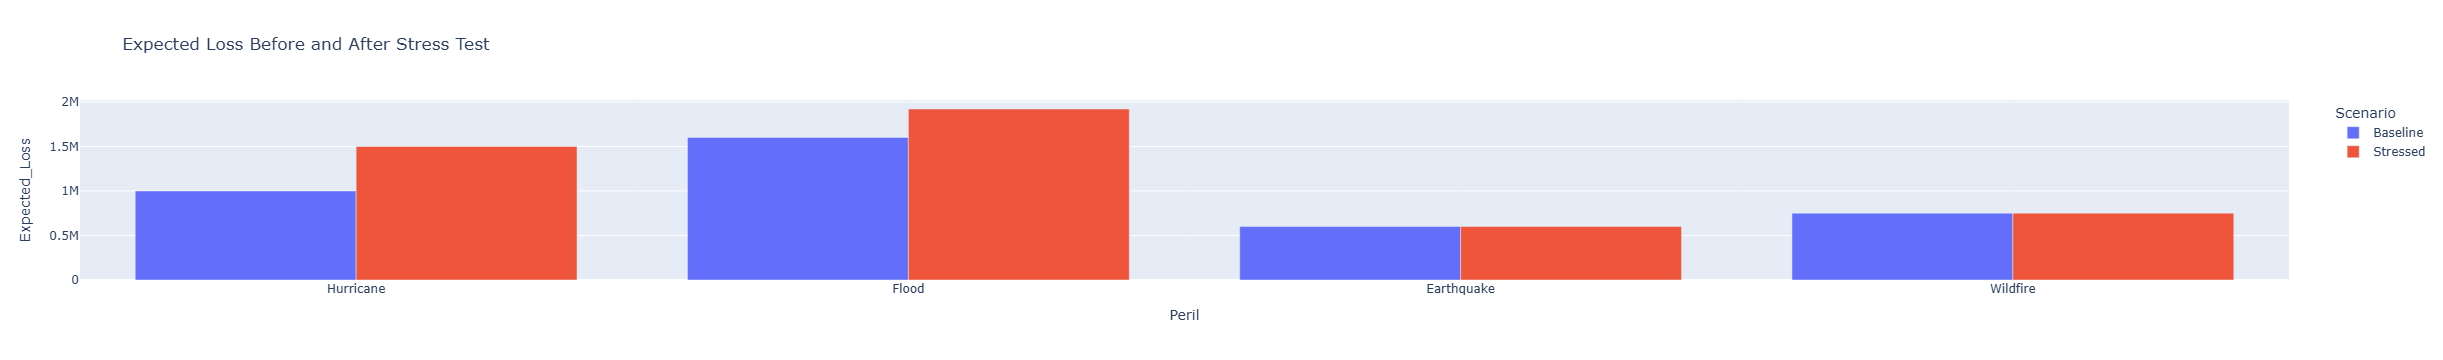

In [11]:
combined = pd.concat([
    portfolio.assign(Scenario='Baseline'),
    stressed_portfolio.assign(Scenario='Stressed')
])

fig = px.bar(
    combined,
    x='Peril',
    y='Expected_Loss',
    color='Scenario',
    barmode='group',
    title='Expected Loss Before and After Stress Test'
)
fig.show()